# Download e visão inicial dos dados

In [3]:
import yfinance as yf
import matplotlib.pyplot as plt
import numpy as np
from matplotlib.patches import Rectangle
from sklearn.preprocessing import MinMaxScaler
from sklearn.model_selection import train_test_split
from pathlib import Path
import pandas as pd
from sklearn.model_selection import TimeSeriesSplit
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense, Dropout
from tensorflow.keras.callbacks import EarlyStopping
from sklearn.metrics import mean_squared_error, mean_absolute_percentage_error
import joblib
import os


In [9]:

data_dir = Path.cwd() / "data"   # Path.cwd() = diretório do notebook
data_dir.mkdir(exist_ok=True)

symbol = 'MSFT'
start_date = '2024-01-01'
end_date = '2025-10-31'

df = yf.download(symbol, start=start_date, end=end_date)
df.to_csv(data_dir / "MSFT.csv", index=False)

/var/folders/22/p5w3pds139513tzr6pglg5_00000gn/T/ipykernel_59529/3763039313.py:8: FutureWarning: YF.download() has changed argument auto_adjust default to True
  df = yf.download(symbol, start=start_date, end=end_date)
[*********************100%***********************]  1 of 1 completed


## Carregandos dados locais

In [2]:
def load_stock(symbol):
    return pd.read_csv(f"data/{symbol}.csv")

In [5]:
df = load_stock("MSFT")

# Analise inicial

In [10]:
print('df info:')
print(df.info)

print(f'is there any NaN?: {df.isnull().any().any()}')


df info:
<bound method DataFrame.info of Price            Close        High         Low        Open    Volume
Ticker            MSFT        MSFT        MSFT        MSFT      MSFT
Date                                                                
2024-01-02  365.421570  370.377673  361.381797  368.367634  25258600
2024-01-03  365.155579  367.776505  363.096286  363.588941  23083500
2024-01-04  362.534698  367.618898  361.776021  365.224604  20901500
2024-01-05  362.347443  366.594123  361.115806  363.549521  21004600
2024-01-08  369.185486  369.688003  363.588937  363.874655  23134000
...                ...         ...         ...         ...       ...
2025-10-24  522.631836  524.368576  519.737290  521.813360  15532400
2025-10-27  530.527100  533.581381  528.021779  530.786624  18734700
2025-10-28  541.057373  552.685573  539.759814  548.972552  29986700
2025-10-29  540.538330  545.249544  535.727327  543.922012  36023000
2025-10-30  524.777832  533.970588  521.144617  529.488985  41

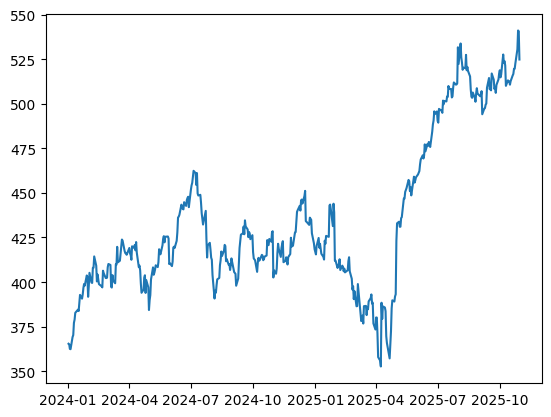

In [11]:
plt.plot(df['Close'])

In [12]:
print('df columns:')
print(df.columns)


df columns:
MultiIndex([( 'Close', 'MSFT'),
            (  'High', 'MSFT'),
            (   'Low', 'MSFT'),
            (  'Open', 'MSFT'),
            ('Volume', 'MSFT')],
           names=['Price', 'Ticker'])


In [13]:
# tirando o segundo nível das colunas
df.columns = df.columns.get_level_values('Price')
df

Price,Close,High,Low,Open,Volume
Date,,,,,
2024-01-02,365.421570,370.377673,361.381797,368.367634,25258600
2024-01-03,365.155579,367.776505,363.096286,363.588941,23083500
2024-01-04,362.534698,367.618898,361.776021,365.224604,20901500
2024-01-05,362.347443,366.594123,361.115806,363.549521,21004600
2024-01-08,369.185486,369.688003,363.588937,363.874655,23134000
...,...,...,...,...,...
2025-10-24,522.631836,524.368576,519.737290,521.813360,15532400
2025-10-27,530.527100,533.581381,528.021779,530.786624,18734700
2025-10-28,541.057373,552.685573,539.759814,548.972552,29986700


In [14]:
df.columns

Index(['Close', 'High', 'Low', 'Open', 'Volume'], dtype='object', name='Price')

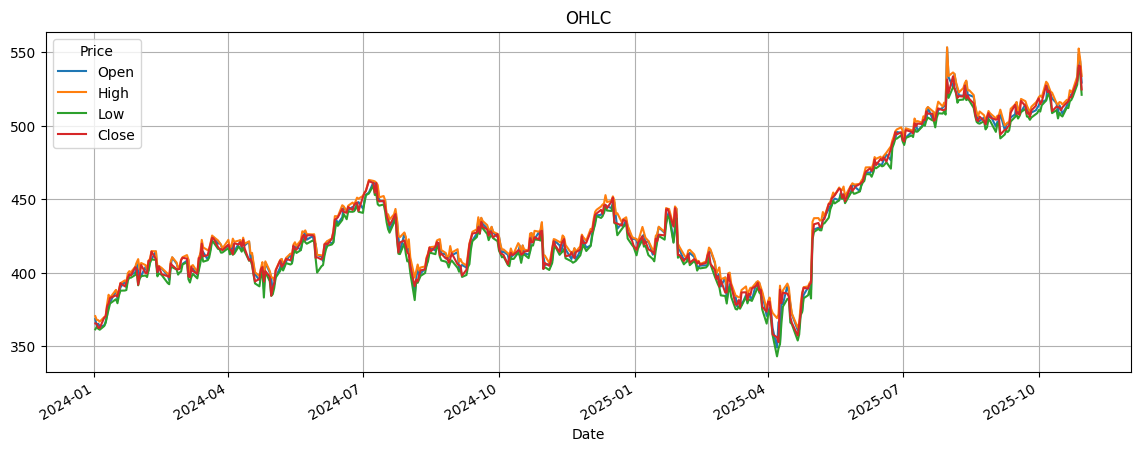

In [15]:
df[['Open', 'High', 'Low', 'Close']].plot(figsize=(14,5))
plt.title("OHLC")
plt.grid(True)
plt.show()


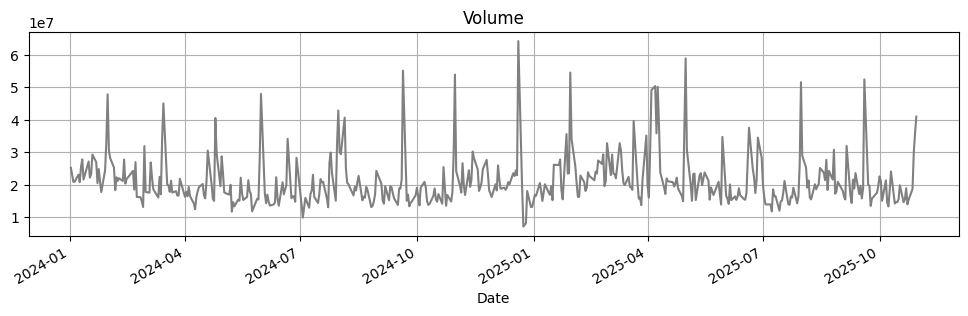

In [16]:
df['Volume'].plot(figsize=(12,3), color='gray')
plt.title("Volume")
plt.grid(True)
plt.show()


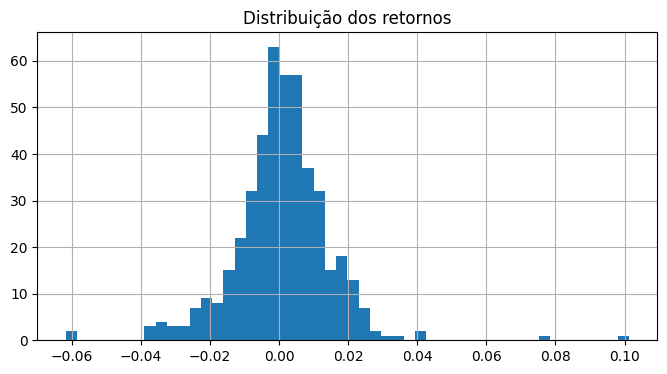

In [17]:
returns = df['Close'].pct_change()
returns.hist(bins=50, figsize=(8,4))
plt.title("Distribuição dos retornos")
plt.grid(True)
plt.show()


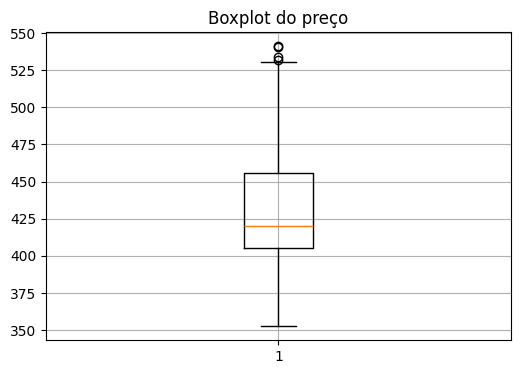

In [18]:
plt.figure(figsize=(6,4))
plt.boxplot(df['Close'].dropna())
plt.title("Boxplot do preço")
plt.grid(True)
plt.show()


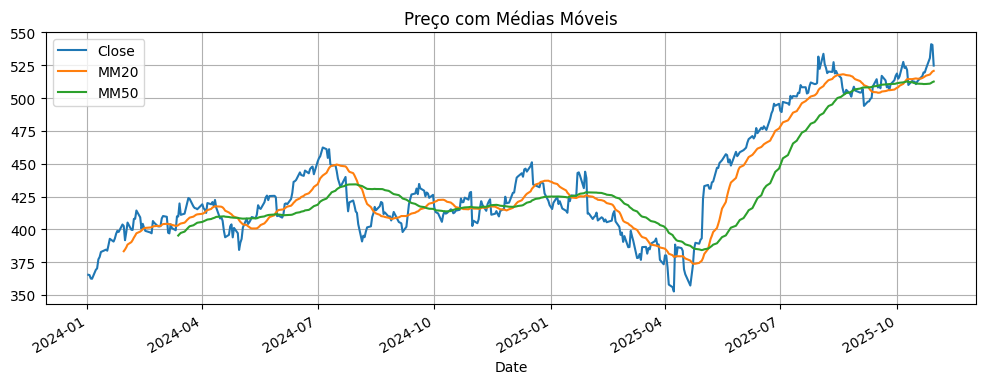

In [19]:
df['Close'].plot(figsize=(12,4), label="Close")
df['Close'].rolling(20).mean().plot(label="MM20")
df['Close'].rolling(50).mean().plot(label="MM50")

plt.title("Preço com Médias Móveis")
plt.legend()
plt.grid(True)
plt.show()


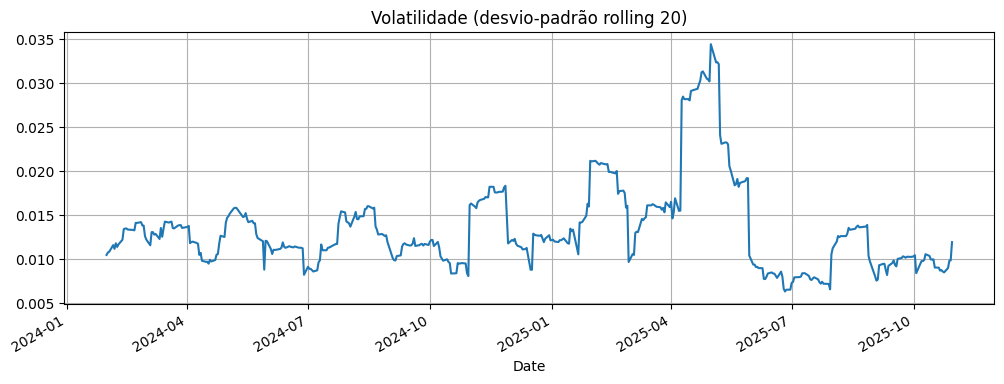

In [20]:
vol = returns.rolling(20).std()

vol.plot(figsize=(12,4))
plt.title("Volatilidade (desvio-padrão rolling 20)")
plt.grid(True)
plt.show()


# Tratando outliers

In [21]:
# Criando função para tratar outliers

def cap_outliers(df, cols, factor=1.5):
    df = df.copy()
    for col in cols:
        Q1 = df[col].quantile(0.25)
        Q3 = df[col].quantile(0.75)
        IQR = Q3 - Q1
        lower = Q1 - factor * IQR
        upper = Q3 + factor * IQR
        print(f'{col} limits: lower: {lower} upper: {upper}')

        df[col] = df[col].clip(lower, upper) #Valores menores que lower são substituídos por lower. Valores maiores que upper são substituídos por upper. Mantém o tamanho do DataFrame → essencial para LSTM. Evita excluir linhas e quebrar a sequência temporal.
    return df


In [22]:
df_sem_outliers = cap_outliers(df, df.columns)

Close limits: lower: 330.4283332824707 upper: 530.8385810852051
High limits: lower: 333.7919758791267 upper: 533.8218275269955
Low limits: lower: 325.9742650011789 upper: 528.8090454176316
Open limits: lower: 331.7281717177756 upper: 527.5596768263259
Volume limits: lower: 5844875.0 upper: 33769275.0


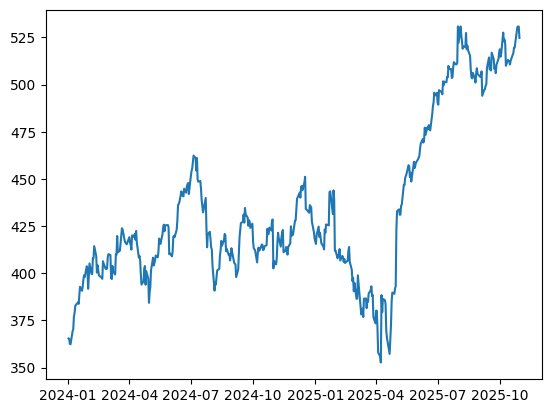

In [23]:
plt.plot(df_sem_outliers['Close'])

# Alternativa 1: Apenas Transformando Dados

In [30]:
# para LSTM (treino = passado / teste = futuro), você separa X e y depois de criar as janelas (windows).

train_size = int(len(df_sem_outliers) * 0.8)

train = df_sem_outliers.iloc[:train_size]
test  = df_sem_outliers.iloc[train_size:]


In [31]:
scaler = MinMaxScaler()
train_scaled = scaler.fit_transform(train)
test_scaled  = scaler.transform(test)


In [37]:
print(f"transformed shape: {train.shape}")
print(f"per-feature minimum before scaling: \n {train.min(axis=0)}")
print(f"per-feature maximum before scaling: \n {train.max(axis=0)}")
print(f"per-feature minimum after scaling: \n {train_scaled.min(axis=0)}")
print(f"per-feature maximum after scaling: \n {train_scaled.max(axis=0)}")

transformed shape: (368, 5)
per-feature minimum before scaling: 
 Price
Close     3.526694e+02
High      3.625365e+02
Low       3.429515e+02
Open      3.490090e+02
Volume    7.164500e+06
dtype: float64
per-feature maximum before scaling: 
 Price
Close     4.785561e+02
High      4.817649e+02
Low       4.751980e+02
Open      4.805392e+02
Volume    3.376928e+07
dtype: float64
per-feature minimum after scaling: 
 [0. 0. 0. 0. 0.]
per-feature maximum after scaling: 
 [1. 1. 1. 1. 1.]


In [38]:
print(f"transformed shape: {test.shape}")
print(f"per-feature minimum before scaling: \n {test.min(axis=0)}")
print(f"per-feature maximum before scaling: \n {test.max(axis=0)}")
print(f"per-feature minimum after scaling: \n {test_scaled.min(axis=0)}")
print(f"per-feature maximum after scaling: \n {test_scaled.max(axis=0)}")

transformed shape: (92, 5)
per-feature minimum before scaling: 
 Price
Close     4.842960e+02
High      4.860398e+02
Low       4.708533e+02
Open      4.765333e+02
Volume    1.184660e+07
dtype: float64
per-feature maximum before scaling: 
 Price
Close     5.308387e+02
High      5.338219e+02
Low       5.288091e+02
Open      5.275597e+02
Volume    3.376928e+07
dtype: float64
per-feature minimum after scaling: 
 [1.04559525 1.0358553  0.96714698 0.9695437  0.17598721]
per-feature maximum after scaling: 
 [1.41531402 1.4366161  1.40538777 1.35748838 1.        ]


In [32]:
# Para LSTMs, você nunca usa “linha atual” como X — você usa um histórico (window).
# Exemplo: usar 30 passos passados para prever o próximo passo.

def create_sequences_multivar(data, window, target_col_index):
    X, y = [], []
    for i in range(window, len(data)):
        X.append(data[i-window:i, :])      # janela com as 5 features
        y.append(data[i, target_col_index]) # apenas o Close
    return np.array(X), np.array(y)


In [33]:
# Você deve criar as janelas separadamente, pois misturar test com train faz vazamento de dados.

window = 30
target_col_index = 0  # "Close"

X_train, y_train = create_sequences_multivar(train_scaled, window, target_col_index)
X_test, y_test   = create_sequences_multivar(test_scaled, window, target_col_index)

In [35]:
print(f"X_train shape: {X_train.shape}")
print(f"y_train shape: {y_train.shape}")
print(f"y_test shape: {X_test.shape}")
print(f"y_test shape: {y_test.shape}")

X_train shape: (338, 30, 5)
y_train shape: (338,)
y_test shape: (62, 30, 5)
y_test shape: (62,)


# Alternativa 2: Transformando dados e treinando modelo


In [24]:
# Para LSTMs, você nunca usa “linha atual” como X — você usa um histórico (window).
# Exemplo: usar 30 passos passados para prever o próximo passo.

def create_sequences_multivar(data, window, target_col_index):
    X, y = [], []
    for i in range(window, len(data)):
        X.append(data[i-window:i, :])      # janela com as 5 features
        y.append(data[i, target_col_index]) # apenas o Close
    return np.array(X), np.array(y)


In [25]:
tscv = TimeSeriesSplit(n_splits=5)
window = 30
target_col_index = 0  # "Close"

In [26]:
y_true_final = None
y_pred_final = None
rmse_final = None
mape_final = None
split_idx_final = None
best_val_loss = float('inf')
best_model = None
best_scaler = None

In [27]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import joblib
from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import mean_squared_error, mean_absolute_percentage_error
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense, Dropout
from tensorflow.keras.callbacks import EarlyStopping

# --- Variáveis para Rastreamento do Melhor Split ---
best_val_loss = float('inf')
best_model = None
best_scaler = None
best_y_true = None
best_y_pred = None
best_rmse = None
best_mape = None
best_split_idx = None
# --------------------------------------------------


for split_idx, (train_idx, val_idx) in enumerate(tscv.split(df)):
    print(f"\n=== Split {split_idx+1} ===")

    # 1 — Divisão temporal do DataFrame original
    train_df = df.iloc[train_idx]
    val_df   = df.iloc[val_idx]

    # 2 — Normalização (fit no train, transform no val)
    scaler = MinMaxScaler()
    train_scaled = scaler.fit_transform(train_df)
    val_scaled   = scaler.transform(val_df)

    # 3 — Criar janelas apenas dentro de cada split
    X_train, y_train = create_sequences_multivar(train_scaled, window, target_col_index)
    X_val, y_val     = create_sequences_multivar(val_scaled, window, target_col_index)

    # Ajuste: remover splits muito pequenos para janela
    if len(X_train) == 0 or len(X_val) == 0:
        print("Split muito pequeno para janela — pulando.")
        continue

    # 4 — Criar o modelo LSTM (Definido DENTRO do loop para garantir um novo modelo a cada split)
    model = Sequential([
        LSTM(64, return_sequences=True, input_shape=(window, df.shape[1])),
        LSTM(64),
        Dense(128, activation='relu'),
        Dropout(0.5),
        Dense(1)
    ])

    # model.summary() # Removido para simplificar a saída do loop
    model.compile(optimizer="adam", loss="mse")

    early_stopping_callback = EarlyStopping(
        monitor='val_loss',
        patience=10,
        restore_best_weights=True,
        verbose=1,
    )

    # 5 — Treinar
    print(f"Treinando modelo para Split {split_idx+1}...")
    model.fit(
        X_train, y_train,
        epochs=20,
        batch_size=32,
        validation_data=(X_val, y_val),
        verbose=0,
        callbacks=[early_stopping_callback]
    )

    # 6 — Avaliar para esse split
    val_loss = model.evaluate(X_val, y_val, verbose=0)
    print(f"Val Loss Split {split_idx+1}: {val_loss:.6f}")


    # ---- 7 — Previsões ----
    y_pred_scaled = model.predict(X_val, verbose=0)

    # ---- 8 — Inverter a escala ----
    dummy_pred  = np.zeros((len(y_pred_scaled), df.shape[1]))
    dummy_true  = np.zeros((len(y_val), df.shape[1]))

    dummy_pred[:, target_col_index] = y_pred_scaled[:, 0]
    dummy_true[:, target_col_index] = y_val

    y_pred = scaler.inverse_transform(dummy_pred)[:, target_col_index]
    y_true = scaler.inverse_transform(dummy_true)[:, target_col_index]

    # ---- 9 — Calcular métricas ----
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    mape = mean_absolute_percentage_error(y_true, y_pred) * 100

    print(f"RMSE Split {split_idx+1}: {rmse:.4f}")
    print(f"MAPE Split {split_idx+1}: {mape:.2f}%")

    # --- LÓGICA DE ATUALIZAÇÃO PARA O MELHOR SPLIT ---
    if val_loss < best_val_loss:
        print(f"*** Novo Melhor Modelo Encontrado! (Loss anterior: {best_val_loss:.6f}) ***")
        best_val_loss = val_loss

        # Salva o estado atual como o melhor
        best_model = model
        best_scaler = scaler
        best_y_true = y_true
        best_y_pred = y_pred
        best_rmse = rmse
        best_mape = mape
        best_split_idx = split_idx + 1


=== Split 1 ===


/Library/Frameworks/Python.framework/Versions/3.12/lib/python3.12/site-packages/keras/src/layers/rnn/rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Treinando modelo para Split 1...
Epoch 14: early stopping
Restoring model weights from the end of the best epoch: 4.
Val Loss Split 1: 0.087353
RMSE Split 1: 18.1758
MAPE Split 1: 3.71%
*** Novo Melhor Modelo Encontrado! (Loss anterior: inf) ***

=== Split 2 ===
Treinando modelo para Split 2...


/Library/Frameworks/Python.framework/Versions/3.12/lib/python3.12/site-packages/keras/src/layers/rnn/rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Epoch 19: early stopping
Restoring model weights from the end of the best epoch: 9.
Val Loss Split 2: 0.005187
RMSE Split 2: 7.2044
MAPE Split 2: 1.43%
*** Novo Melhor Modelo Encontrado! (Loss anterior: 0.087353) ***

=== Split 3 ===
Treinando modelo para Split 3...


...

Restoring model weights from the end of the best epoch: 18.
Val Loss Split 3: 0.011672
RMSE Split 3: 10.8068
MAPE Split 3: 2.10%

=== Split 4 ===
Treinando modelo para Split 4...


/Library/Frameworks/Python.framework/Versions/3.12/lib/python3.12/site-packages/keras/src/layers/rnn/rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Restoring model weights from the end of the best epoch: 14.
Val Loss Split 4: 0.015710
RMSE Split 4: 12.5376
MAPE Split 4: 2.30%

=== Split 5 ===
Treinando modelo para Split 5...


/Library/Frameworks/Python.framework/Versions/3.12/lib/python3.12/site-packages/keras/src/layers/rnn/rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Restoring model weights from the end of the best epoch: 19.
Val Loss Split 5: 0.002170
RMSE Split 5: 7.0523
MAPE Split 5: 1.09%
*** Novo Melhor Modelo Encontrado! (Loss anterior: 0.005187) ***


# Salvando o modelo


🏆 Melhor Split Encontrado: 5 (Val Loss: 0.002170)

✅ Melhor Modelo salvo em: /Users/tiagoribeiro/PycharmProjects/5mlet-tc4-lstm/model/melhor_modelo_lstm.keras
✅ Scaler correspondente salvo em: /Users/tiagoribeiro/PycharmProjects/5mlet-tc4-lstm/model/melhor_scaler_minmax.joblib
✅ Gráfico de comparação salvo em: comparacao_previsao_melhor_split.png
✅ Arquivo CSV de comparação salvo em: previsao_e_real_melhor_split.csv


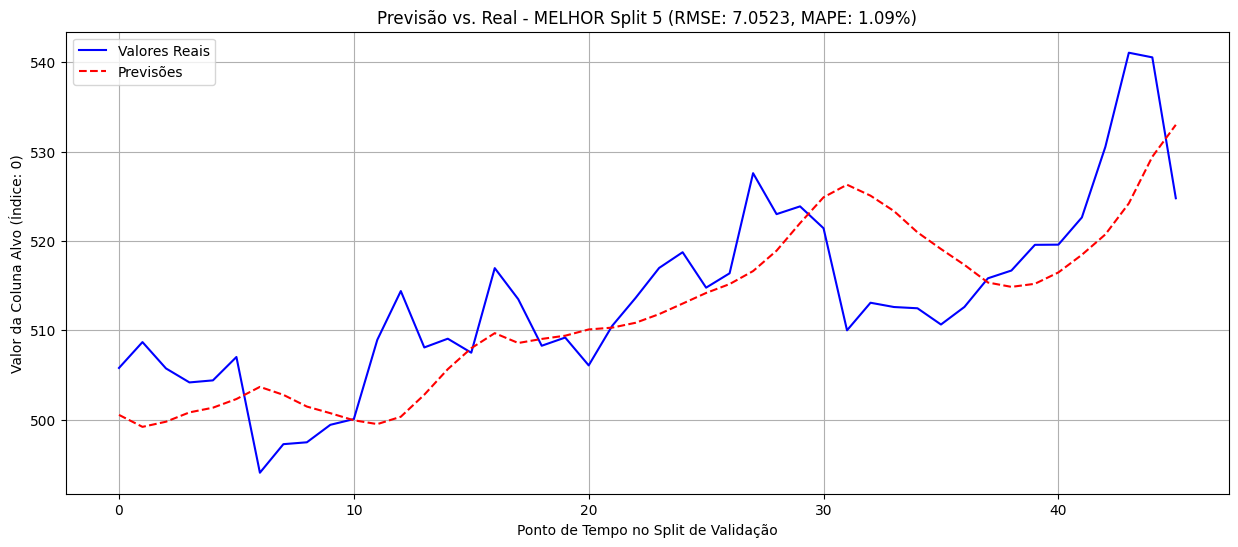

In [30]:

CURRENT_DIR = os.getcwd()
PROJECT_ROOT = os.path.dirname(CURRENT_DIR)
MODEL_PATH = os.path.join(PROJECT_ROOT, "model")

os.makedirs(MODEL_PATH, exist_ok=True)



if best_model is not None:
    print("\n" + "="*50)
    print(f"🏆 Melhor Split Encontrado: {best_split_idx} (Val Loss: {best_val_loss:.6f})")
    print("="*50)

    # --- Salvamento (Modelo e Scaler) ---
    model_filename = 'melhor_modelo_lstm.keras'
    scaler_filename = 'melhor_scaler_minmax.joblib'

    model_path = os.path.join(MODEL_PATH, model_filename)
    best_model.save(model_path)

    print(f"\n✅ Melhor Modelo salvo em: {model_path}")

    scaler_path = os.path.join(MODEL_PATH, scaler_filename)
    joblib.dump(best_scaler, scaler_path)
    print(f"✅ Scaler correspondente salvo em: {scaler_path}")


    # --- Visualização e Salvamento dos Resultados ---

    # 10 — Plotar a comparação do MELHOR SPLIT
    plt.figure(figsize=(15, 6))
    plt.plot(best_y_true, label='Valores Reais', color='blue')
    plt.plot(best_y_pred, label='Previsões', color='red', linestyle='--')
    plt.title(f'Previsão vs. Real - MELHOR Split {best_split_idx} (RMSE: {best_rmse:.4f}, MAPE: {best_mape:.2f}%)')
    plt.xlabel('Ponto de Tempo no Split de Validação')
    plt.ylabel(f'Valor da Coluna Alvo (Índice: {target_col_index})')
    plt.legend()
    plt.grid(True)
    plot_filename = 'comparacao_previsao_melhor_split.png'
    plt.savefig(plot_filename)
    print(f"✅ Gráfico de comparação salvo em: {plot_filename}")

    # 11 — Salvar os dados de comparação do MELHOR SPLIT
    comparacao_df = pd.DataFrame({'Real': best_y_true, 'Previsao': best_y_pred})
    csv_filename = 'previsao_e_real_melhor_split.csv'
    comparacao_df.to_csv(csv_filename, index=False)
    print(f"✅ Arquivo CSV de comparação salvo em: {csv_filename}")

else:
    print("\nNão foi possível treinar/salvar nenhum modelo com sucesso.")

# Testando o modelo


In [8]:

data_dir = Path.cwd() / "data"   # Path.cwd() = diretório do notebook
data_dir.mkdir(exist_ok=True)

symbol = 'MSFT'
start_date = '2025-10-31'
end_date = '2025-12-15'

df = yf.download(symbol, start=start_date, end=end_date)
df.to_csv(data_dir / "MSFT.csv", index=False)

/var/folders/22/p5w3pds139513tzr6pglg5_00000gn/T/ipykernel_53604/1593146564.py:8: FutureWarning: YF.download() has changed argument auto_adjust default to True
  df = yf.download(symbol, start=start_date, end=end_date)
[*********************100%***********************]  1 of 1 completed


In [9]:
    # tirando o segundo nível das colunas
df.columns = df.columns.get_level_values('Price')
df

Price,Close,High,Low,Open,Volume
Date,,,,,
2025-10-31,516.842651,528.331159,514.137692,527.891978,34006400
2025-11-03,516.064148,523.979326,513.628704,518.838923,22374700
2025-11-04,513.369202,514.586893,506.891305,510.803995,20958700
2025-11-05,506.212555,513.868240,505.633621,512.341069,23024300
2025-11-06,496.171356,504.755296,494.883758,504.715363,27406500
2025-11-07,495.891876,498.447091,492.328538,496.021638,24019800
2025-11-10,505.054718,505.903136,497.868156,499.105861,26101500
2025-11-11,507.729706,508.648001,501.411545,503.856949,17980000
2025-11-12,510.185150,510.714159,498.187585,508.408446,26574900


In [10]:
import pandas as pd
import json


data = df.values
# O mé tolist() converte o array 2D NumPy em uma lista de listas Python,
# que é o formato exato que a API espera para a chave 'data'.
payload_data = data.tolist()

# Estrutura final do JSON (o payload)
payload = {
    "data": payload_data
}

# --- 5. Exportar ou Visualizar o JSON ---

# Imprime o JSON formatado para você copiar e colar no Swagger UI
print("\n--- JSON Payload para o Endpoint /predict ---\n")
json_payload = json.dumps(payload, indent=2)
print(json_payload)

# Exemplo de como você pode salvar em um arquivo para uso posterior
with open('test_payload.json', 'w') as f:
    f.write(json_payload)

print("\n--- Payload salvo em 'test_payload.json' ---")


--- JSON Payload para o Endpoint /predict ---

{
  "data": [
    [
      516.8426513671875,
      528.3311587204174,
      514.137692119172,
      527.8919782690999,
      34006400.0
    ],
    [
      516.0641479492188,
      523.9793263365088,
      513.628703759196,
      518.8389228578652,
      22374700.0
    ],
    [
      513.3692016601562,
      514.5868933466259,
      506.8913048594995,
      510.80399534425794,
      20958700.0
    ],
    [
      506.2125549316406,
      513.8682396575209,
      505.6336213981725,
      512.3410686781482,
      23024300.0
    ],
    [
      496.1713562011719,
      504.75529633258907,
      494.88375756631746,
      504.7153625290288,
      27406500.0
    ],
    [
      495.8918762207031,
      498.4470913363115,
      492.32853818272196,
      496.02163823572937,
      24019800.0
    ],
    [
      505.0547180175781,
      505.9031361854127,
      497.8681564860657,
      499.10586069795033,
      26101500.0
    ],
    [
      507.72970581

In [5]:
df.columns

Index(['Close', 'High', 'Low', 'Open', 'Volume'], dtype='object', name='Price')